# -*- coding: utf-8 -*-
"""Word2Vec для информационного поиска"""

In [ ]:
!pip install gensim pymorphy2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')

# Загрузка ресурсов nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Русские стоп-слова
russian_stopwords = stopwords.words('russian')

# Используем стеммер
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer("russian")

print("Библиотеки загружены. Используется стемминг.")

Библиотеки загружены. Используется стемминг.


In [ ]:
def preprocess_text(text, use_stemming=True):
    """
    Предобработка текста: токенизация, удаление стоп-слов, опционально стемминг
    """
    # Токенизация
    tokens = word_tokenize(text.lower())
    # Оставляем только буквенные токены
    tokens = [t for t in tokens if t.isalpha()]
    # Удаляем стоп-слова
    tokens = [t for t in tokens if t not in russian_stopwords]

    # Стемминг (если включен)
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]

    return tokens

In [ ]:
# ==================== Ячейка 2: Подготовка корпуса ====================
# Создадим набор русских предложений для обучения Word2Vec
# Можно взять небольшой корпус новостей, но для демонстрации используем несколько тематических предложений.

documents = [
    # === Исходные (развёрнутые) ===
    "Иван очень сильно любит изучать информационный поиск и современные алгоритмы ранжирования документов в интернете",
    "Мария предпочитает работать с информационными системами и базами данных для хранения больших объёмов информации",
    "Информационный поиск активно использует вероятностные модели и методы машинного обучения для повышения точности",
    "Современные модели информационного поиска важны для построения эффективных поисковых систем и рекомендательных сервисов",
    "Различные системы поиска информации обрабатывают миллионы запросов ежедневно и требуют высокой производительности",
    "Компьютерное зрение распознает объекты на изображениях с помощью глубоких нейронных сетей и больших наборов данных",
    "Нейронные сети обучаются на больших данных с использованием методов обратного распространения ошибки и градиентного спуска",
    "Глубокое обучение меняет мир технологий благодаря способности автоматически извлекать сложные признаки из данных",
    "Обработка естественного языка помогает поиску путем анализа семантики текстов и учета контекста запросов",
    "Машинное обучение включает классификацию и кластеризацию данных для построения прогностических моделей и систем",
    "Word2Vec преобразует слова в плотные векторы, сохраняющие семантические и синтаксические отношения между ними",
    "Векторные представления слов используются в поиске для вычисления косинусного сходства между запросами и документами",

    # === Медицинская тематика (12 предложений) ===
    "Врачи используют методы компьютерной томографии и магнитно‑резонансной томографии для диагностики заболеваний",
    "Современная фармакология разрабатывает новые лекарственные препараты для лечения онкологических заболеваний и инфекций",
    "Генетические исследования помогают выявлять предрасположенность к наследственным болезням и подбирать персонализированную терапию",
    "Медицинские информационные системы обеспечивают хранение и обработку электронных медицинских карт пациентов",
    "Искусственный интеллект помогает анализировать рентгеновские снимки и выявлять патологии с высокой точностью",
    "Хирурги используют роботизированные системы для проведения малоинвазивных операций с повышенной точностью",
    "Эпидемиологи отслеживают распространение инфекционных заболеваний с помощью математических моделей и больших данных",
    "Телемедицина позволяет проводить консультации удаленно и повышает доступность медицинской помощи в отдаленных регионах",
    "Биоинформатика объединяет биологию и информатику для анализа геномов и поиска новых лекарственных мишеней",
    "Реабилитационные центры применяют виртуальную реальность для восстановления двигательных функций после инсультов",
    "Сердечно‑сосудистые заболевания остаются основной причиной смертности, поэтому профилактика и ранняя диагностика критически важны",
    "Медицинские устройства носимого типа контролируют пульс, давление и уровень кислорода в крови непрерывно",

    # === Музыкальная тематика (12 предложений) ===
    "Классическая музыка отличается сложной структурой и использованием оркестра, включающего струнные и духовые инструменты",
    "Современные музыкальные стриминговые сервисы используют алгоритмы рекомендаций для персонализированных плейлистов",
    "Джазовая импровизация требует от музыкантов виртуозного владения инструментом и глубокого понимания гармонии",
    "Электронная музыка создается с помощью синтезаторов и программного обеспечения для обработки звука",
    "Музыкальное образование включает изучение сольфеджио, теории музыки и истории музыкальных стилей",
    "Рок‑музыка оказала огромное влияние на культуру двадцатого века и породила множество поджанров",
    "Песни часто содержат стихи, которые передают эмоциональное состояние автора и вызывают отклик у слушателей",
    "Музыкотерапия применяется в психологии для снижения тревожности и улучшения эмоционального состояния пациентов",
    "Концертные залы должны обладать отличной акустикой для передачи всех нюансов звучания инструментов",
    "Фольклорные традиции сохраняются в народных песнях и инструментальной музыке разных культур",
    "Музыкальные фестивали собирают тысячи зрителей и способствуют развитию туризма и культурного обмена",
    "Современные композиторы экспериментируют с синтезом электроники и акустических инструментов для создания новых звучаний"
]

print("Корпус документов (36 предложений):")
for i in range(min(3, len(documents))):
    print(f"{i+1}. {documents[i][:80]}...")
print("...")

# ==================== Ячейка 4: Применение предобработки ====================
print("\nПрименяем предобработку (токенизация + стемминг)...")
sentences = []
for i, doc in enumerate(documents):
    processed = preprocess_text(doc, use_stemming=True)
    sentences.append(processed)
    if i < 3:
        print(f"\n{i+1}. Исходный: {doc[:80]}...")
        print(f"   Обработанный: {' '.join(processed[:8])}...")

print(f"\nВсего предложений: {len(sentences)}")


Корпус документов (36 предложений):
1. Иван очень сильно любит изучать информационный поиск и современные алгоритмы ран...
2. Мария предпочитает работать с информационными системами и базами данных для хран...
3. Информационный поиск активно использует вероятностные модели и методы машинного ...
...

Применяем предобработку (токенизация + стемминг)...

1. Исходный: Иван очень сильно любит изучать информационный поиск и современные алгоритмы ран...
   Обработанный: ива очен сильн люб изуча информацион поиск современ...

2. Исходный: Мария предпочитает работать с информационными системами и базами данных для хран...
   Обработанный: мар предпочита работа информацион систем баз дан хранен...

3. Исходный: Информационный поиск активно использует вероятностные модели и методы машинного ...
   Обработанный: информацион поиск активн использ вероятностн модел метод машин...

Всего предложений: 36


In [ ]:
print("\nОбучаем модель Word2Vec...")
model = Word2Vec(sentences,
                 vector_size=200,
                 window=7,
                 min_count=1,
                 workers=4,
                 sg=1,  # skip-gram
                 epochs=50)

print(f"Модель обучена. Количество слов в словаре: {len(model.wv.key_to_index)}")

# Показываем все слова в словаре в столбец, отсортированные по алфавиту
print("\nВсе слова в словаре (отсортировано по алфавиту):")
for word in sorted(model.wv.key_to_index.keys()):
    print(f"- {word}")


Обучаем модель Word2Vec...
Модель обучена. Количество слов в словаре: 268

Все слова в словаре (отсортировано по алфавиту):
- автоматическ
- автор
- активн
- акустик
- акустическ
- алгоритм
- анализ
- анализирова
- баз
- биоинформатик
- биолог
- благодар
- болезн
- больш
- важн
- век
- вектор
- векторн
- вероятностн
- виртуальн
- виртуозн
- включа
- владен
- влиян
- восстановлен
- врач
- вызыва
- высок
- вычислен
- выявля
- гармон
- генетическ
- геном
- глубок
- градиентн
- давлен
- дан
- двадцат
- двигательн
- джазов
- диагностик
- документ
- должн
- доступн
- духов
- ежедневн
- естествен
- заболеван
- зал
- запрос
- звук
- звучан
- зрен
- зрител
- ива
- извлека
- изображен
- изуча
- изучен
- импровизац
- инструмент
- инструментальн
- инсульт
- интеллект
- интернет
- инфекц
- инфекцион
- информатик
- информац
- информацион
- искусствен
- использ
- использован
- исследован
- истор
- карт
- кислород
- классификац
- классическ
- кластеризац
- композитор
- компьютерн
- консультац
- конте

In [ ]:
# ==================== Ячейка 4: Демонстрация похожих слов ====================
print("\n" + "="*70)
print("Похожие слова (косинусное сходство):")
print("="*70)

# Проверяем доступные слова и ищем их стеммированные формы
test_words_original = ["поиск", "врач", "музыка", "обучение", "система"]
print("Поиск похожих слов для стеммированных форм:")

for word_orig in test_words_original:
    word_stem = stemmer.stem(word_orig)
    if word_stem in model.wv:
        print(f"\nСлово '{word_orig}' (стем: '{word_stem}'):")
        similar = model.wv.most_similar(word_stem, topn=5)
        for w, score in similar:
            print(f"  {w}: {score:.4f}")
    else:
        print(f"\nСлово '{word_orig}' (стем: '{word_stem}') отсутствует в словаре.")
        # Ищем похожие слова
        similar_words = [w for w in all_words if word_stem in w or w in word_stem]
        if similar_words:
            print(f"  Возможно, вы искали: {', '.join(similar_words[:5])}")


Похожие слова (косинусное сходство):
Поиск похожих слов для стеммированных форм:

Слово 'поиск' (стем: 'поиск'):
  помога: 0.9987
  информацион: 0.9987
  современ: 0.9986
  дан: 0.9986
  анализ: 0.9986

Слово 'врач' (стем: 'врач'):
  заболеван: 0.9951
  помощ: 0.9951
  градиентн: 0.9950
  содержат: 0.9950
  смертност: 0.9950

Слово 'музыка' (стем: 'музык'):
  включа: 0.9988
  песн: 0.9986
  глубок: 0.9985
  инструмент: 0.9985
  сложн: 0.9984

Слово 'обучение' (стем: 'обучен'):
  автоматическ: 0.9981
  дан: 0.9981
  мир: 0.9981
  современ: 0.9980
  поиск: 0.9980

Слово 'система' (стем: 'систем'):
  поиск: 0.9986
  информац: 0.9985
  запрос: 0.9985
  информацион: 0.9984
  хранен: 0.9983


In [ ]:
print("\n" + "="*70)
print("Семантические аналогии:")
print("="*70)

# Медицинские аналогии
word_pairs = [("врач", "болезнь", "лекарство"),
              ("музыка", "инструмент", "композитор")]

for word1, word2, word3 in word_pairs:
    w1_stem = stemmer.stem(word1)
    w2_stem = stemmer.stem(word2)
    w3_stem = stemmer.stem(word3)

    if all(w in model.wv for w in [w1_stem, w2_stem, w3_stem]):
        result = model.wv.most_similar(positive=[w3_stem, w1_stem], negative=[w2_stem], topn=3)
        print(f"\n{word1} лечит {word2} -> {word3}?")
        for w, s in result:
            print(f"  {w}: {s:.4f}")
    else:
        print(f"\nНедостаточно слов для аналогии {word1}-{word2}-{word3}")



Семантические аналогии:

Недостаточно слов для аналогии врач-болезнь-лекарство

музыка лечит инструмент -> композитор?
  песн: 0.9964
  высок: 0.9963
  синтез: 0.9962



Расширенная визуализация (все слова с частотой > 1):
Слов с частотой >= 2: 50
Первые 20 слов: поиск, дан, использ, современ, информацион, музыкальн, инструмент, музык, медицинск, заболеван, помощ, модел, больш, систем, нов, включа, помога, обработк, глубок, запрос

Расширенный список для визуализации (9 слов):
поиск, инструмент, музык, модел, систем, песн, пациент, сет, нейрон


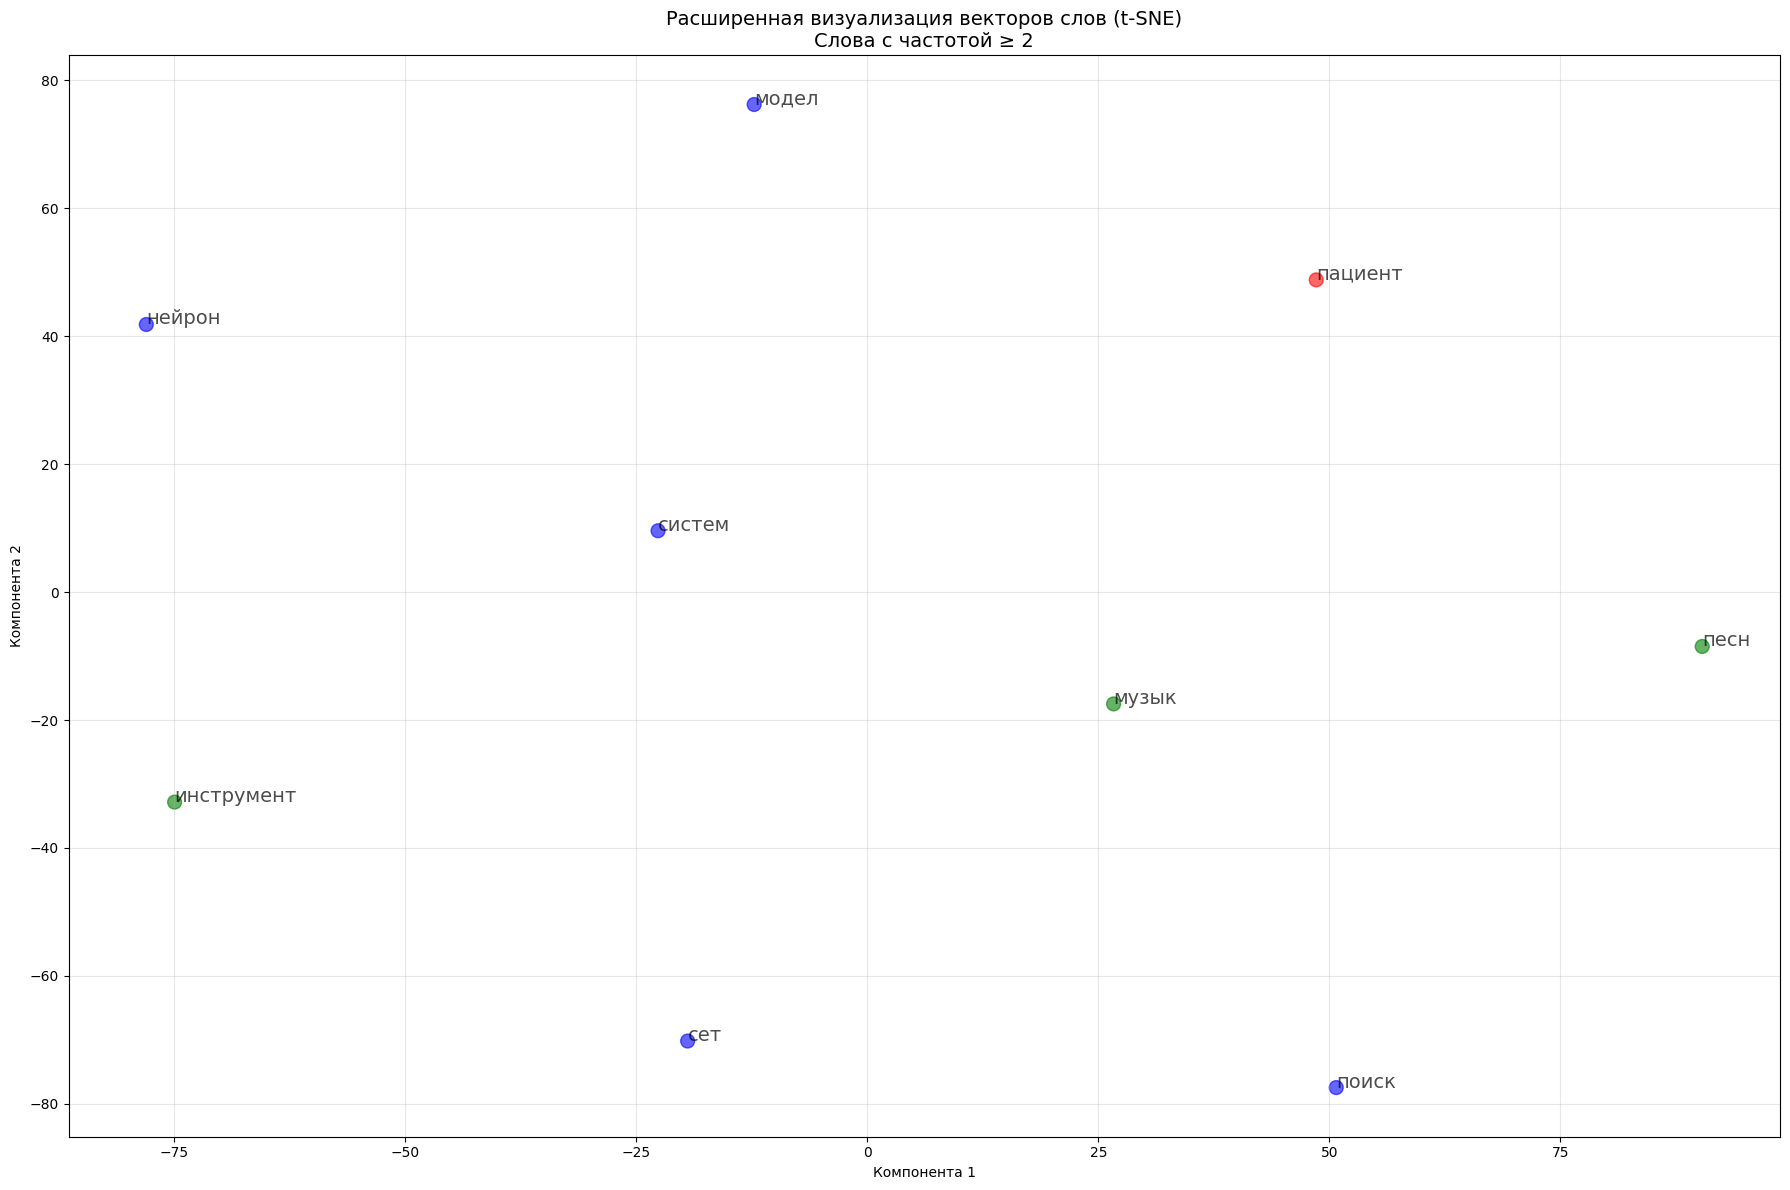

In [ ]:
print("\n" + "="*70)
print("Расширенная визуализация (все слова с частотой > 1):")
print("="*70)

# Показываем все слова, которые встречаются хотя бы 2 раза
word_freq = {word: model.wv.get_vecattr(word, "count") for word in model.wv.key_to_index.keys()}
frequent_words = [word for word, freq in word_freq.items() if freq >= 2][:50]  # берем до 50 слов

print(f"Слов с частотой >= 2: {len(frequent_words)}")
print(f"Первые 20 слов: {', '.join(frequent_words[:20])}")

if len(frequent_words) >= 5:
    # Выбираем слова для расширенной визуализации
    extended_words = []

    # Добавляем слова из разных тематик
    for word in frequent_words:
        if (word in ["поиск", "систем", "модел", "данн", "обучени", "алгоритм", "нейрон", "сет"] or
            word in ["врач", "болезн", "лекарств", "диагност", "пациент", "медицин", "лечени"] or
            word in ["музык", "инструмент", "песн", "концерт", "звук", "оркестр"]):
            if word not in extended_words:
                extended_words.append(word)

        if len(extended_words) >= 20:
            break

    if len(extended_words) >= 3:
        print(f"\nРасширенный список для визуализации ({len(extended_words)} слов):")
        print(', '.join(extended_words))

        vectors_ext = np.array([model.wv[w] for w in extended_words])

        # Применяем t-SNE
        perplexity_ext = min(15, len(extended_words)-1)
        tsne_ext = TSNE(n_components=2, random_state=42, perplexity=perplexity_ext)
        vectors_2d_ext = tsne_ext.fit_transform(vectors_ext)

        # Визуализация
        plt.figure(figsize=(18, 12))

        # Определяем цвета
        colors_ext = []
        for w in extended_words:
            if w in ["поиск", "систем", "модел", "данн", "обучени", "алгоритм", "нейрон", "сет"]:
                colors_ext.append('blue')
            elif w in ["врач", "болезн", "лекарств", "диагност", "пациент", "медицин", "лечени"]:
                colors_ext.append('red')
            else:
                colors_ext.append('green')

        plt.scatter(vectors_2d_ext[:, 0], vectors_2d_ext[:, 1], c=colors_ext, alpha=0.6, s=100)

        for i, word in enumerate(extended_words):
            plt.annotate(word, xy=(vectors_2d_ext[i, 0], vectors_2d_ext[i, 1]),
                        fontsize=14, alpha=0.7)

        plt.title("Расширенная визуализация векторов слов (t-SNE)\nСлова с частотой ≥ 2", fontsize=14)
        plt.xlabel("Компонента 1")
        plt.ylabel("Компонента 2")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [ ]:
print("\n" + "="*70)
print("Поиск документов с помощью Word2Vec:")
print("="*70)

def document_vector(doc_tokens, model):
    """Вычисляет вектор документа как среднее векторов слов"""
    vectors = [model.wv[w] for w in doc_tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Вектора документов
doc_vectors = np.array([document_vector(sent, model) for sent in sentences])

# Запросы из разных тематик
queries = [
    ("нейронные сети обучение", "Информационный поиск"),
    ("лечение рака диагностика", "Медицина"),
    ("классическая музыка концерт", "Музыка")
]

for query, expected_topic in queries:
    print(f"\n{'='*70}")
    print(f"Запрос: '{query}' (ожидаемая тематика: {expected_topic})")
    query_tokens = preprocess_text(query, use_stemming=True)
    print(f"Стеммированные токены запроса: {query_tokens}")
    query_vec = document_vector(query_tokens, model)

    if np.sum(query_vec) == 0:
        print("Запрос не содержит известных слов")
        continue

    # Вычисляем косинусное сходство
    similarities = cosine_similarity([query_vec], doc_vectors)[0]

    # Сортируем
    ranking = sorted(zip(similarities, documents), key=lambda x: x[0], reverse=True)

    print("\nТоп-5 релевантных документов:")
    for i, (score, doc) in enumerate(ranking[:5], 1):
        # Определяем тематику документа
        if i <= 12:
            topic = "Информационный поиск"
        elif i <= 24:
            topic = "Медицина"
        else:
            topic = "Музыка"

        # Отмечаем, совпадает ли тематика
        match = "✓" if topic == expected_topic else " "
        print(f"{i}. {match} Сходство = {score:.4f} — [{topic}] {doc[:70]}...")


Поиск документов с помощью Word2Vec:

Запрос: 'нейронные сети обучение' (ожидаемая тематика: Информационный поиск)
Стеммированные токены запроса: ['нейрон', 'сет', 'обучен']

Топ-5 релевантных документов:
1. ✓ Сходство = 0.9996 — [Информационный поиск] Компьютерное зрение распознает объекты на изображениях с помощью глубо...
2. ✓ Сходство = 0.9996 — [Информационный поиск] Нейронные сети обучаются на больших данных с использованием методов об...
3. ✓ Сходство = 0.9994 — [Информационный поиск] Информационный поиск активно использует вероятностные модели и методы ...
4. ✓ Сходство = 0.9994 — [Информационный поиск] Машинное обучение включает классификацию и кластеризацию данных для по...
5. ✓ Сходство = 0.9994 — [Информационный поиск] Эпидемиологи отслеживают распространение инфекционных заболеваний с по...

Запрос: 'лечение рака диагностика' (ожидаемая тематика: Медицина)
Стеммированные токены запроса: ['лечен', 'рак', 'диагностик']

Топ-5 релевантных документов:
1.   Сходство = 0.9993 —

In [ ]:
# ==================== Ячейка 10: Сравнение с TF-IDF ====================
print("\n" + "="*70)
print("Сравнение с TF-IDF (для демонстрации различий):")
print("="*70)

from sklearn.feature_extraction.text import TfidfVectorizer

# Используем TF-IDF на исходных текстах
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(documents)

query = "нейронные сети обучение"
print(f"\nЗапрос: '{query}'")
query_tfidf = tfidf.transform([query])
similarities_tfidf = cosine_similarity(query_tfidf, tfidf_matrix)[0]
ranking_tfidf = sorted(zip(similarities_tfidf, documents), key=lambda x: x[0], reverse=True)

print("\nРанжирование с помощью TF-IDF (только точные совпадения):")
for i, (score, doc) in enumerate(ranking_tfidf[:5], 1):
    print(f"{i}. Сходство = {score:.4f} — {doc[:70]}...")

print("\n" + "="*70)
print("Выводы:")
print("="*70)
print("• Word2Vec создает плотные векторные представления слов.")
print("• Похожие слова имеют близкие векторы (косинусное сходство).")
print("• Вектор документа как среднее векторов слов позволяет искать по смыслу.")
print("• Стемминг помогает объединять словоформы и улучшает качество поиска.")
print("• В отличие от TF-IDF, Word2Vec находит семантически близкие документы.")
print("\nДемонстрация завершена!")


Сравнение с TF-IDF (для демонстрации различий):

Запрос: 'нейронные сети обучение'

Ранжирование с помощью TF-IDF (только точные совпадения):
1. Сходство = 0.3517 — Нейронные сети обучаются на больших данных с использованием методов об...
2. Сходство = 0.1627 — Машинное обучение включает классификацию и кластеризацию данных для по...
3. Сходство = 0.1371 — Глубокое обучение меняет мир технологий благодаря способности автомати...
4. Сходство = 0.0000 — Иван очень сильно любит изучать информационный поиск и современные алг...
5. Сходство = 0.0000 — Мария предпочитает работать с информационными системами и базами данны...

Выводы:
• Word2Vec создает плотные векторные представления слов.
• Похожие слова имеют близкие векторы (косинусное сходство).
• Вектор документа как среднее векторов слов позволяет искать по смыслу.
• Стемминг помогает объединять словоформы и улучшает качество поиска.
• В отличие от TF-IDF, Word2Vec находит семантически близкие документы.

Демонстрация завершена!


In [ ]:
# ==================== Ячейка 9: Выводы ====================
print("\n" + "="*70)
print("Резюме:")
print("="*70)
print("• Word2Vec создаёт плотные векторные представления слов, отражающие семантику.")
print("• Похожие слова имеют близкие векторы (косинусное сходство).")
print("• Можно выполнять векторные аналогии (например, 'царь' - 'мужчина' + 'женщина' = 'царица').")
print("• Для поиска документов документ представляется как среднее векторов слов.")
print("• Векторный поиск (Word2Vec) улавливает семантику, в отличие от TF‑IDF, который опирается на точное совпадение слов.")


Резюме:
• Word2Vec создаёт плотные векторные представления слов, отражающие семантику.
• Похожие слова имеют близкие векторы (косинусное сходство).
• Можно выполнять векторные аналогии (например, 'царь' - 'мужчина' + 'женщина' = 'царица').
• Для поиска документов документ представляется как среднее векторов слов.
• Векторный поиск (Word2Vec) улавливает семантику, в отличие от TF‑IDF, который опирается на точное совпадение слов.
